In [1]:
# Łączy domyślne 28 klas na mniejszą ilość klas zgodnie z poniższą zależnością:


# Defaultowe kodowanie klas w folderze segmentation_colored
# CARLA_COLORED_CLASSES = {
#     (0, 0, 0): "Unlabeled",
#     (128, 64, 128): "Roads",
#     (244, 35, 232): "SideWalks",
#     (70, 70, 70): "Building",
#     (102, 102, 156): "Wall",
#     (190, 153, 153): "Fence",
#     (153, 153, 153): "Pole",
#     (250, 170, 30): "TrafficLight",
#     (220, 220, 0): "TrafficSign",
#     (107, 142, 35): "Vegetation",
#     (152, 251, 152): "Terrain",
#     (70, 130, 180): "Sky",
#     (220, 20, 60): "Pedestrian",
#     (255, 0, 0): "Rider",
#     (0, 0, 142): "Car",
#     (0, 0, 70): "Truck",
#     (0, 60, 100): "Bus",
#     (0, 80, 100): "Train",
#     (0, 0, 230): "Motorcycle",
#     (119, 11, 32): "Bicycle",
#     (110, 190, 160): "Static",
#     (170, 120, 50): "Dynamic",
#     (55, 90, 80): "Other",
#     (45, 60, 150): "Water",
#     (157, 234, 50): "RoadLine",
#     (81, 0, 81): "Ground",
#     (150, 100, 100): "Bridge",
#     (230, 150, 140): "RailTrack",
#     (180, 165, 180): "GuardRail"
# }

# Defaultowe kodowanie klas w folderze segmentation_raw
# {     0: "Unlabeled",     1: "Roads",     2: "SideWalks",     3: "Building",
#      4: "Wall",     5: "Fence",     6: "Pole",     7: "TrafficLight",     
# 8: "TrafficSign",     9: "Vegetation",     10: "Terrain",     11: "Sky",     
# 12: "Pedestrian",     13: "Rider",     14: "Car",     15: "Truck",     
# 16: "Bus",     17: "Train",     18: "Motorcycle",     19: "Bicycle",     
# 20: "Static",       21: "Dynamic",    22: "Other",      23: "Water",     
# 24: "RoadLine",     25: "Ground",     26: "Bridge",     27: "RailTrack",     28: "GuardRail"}

# Docelowe kodowanie klas po przekształceniu (segmentation_colored):
# 13 klas — indeks raw (0–12) = kolor docelowy. Przy merge wszystkie wymienione RGB źródłowe → ten sam kolor.
#
# MERGED_COLORED_CLASSES = {
#     (0, 0, 0): "Unlabeled",              # 0
#     (128, 64, 128): "Road",              # 1  ← (128, 64, 128) Roads
#     (157, 234, 50): "RoadLine",           # 2  ← (157, 234, 50) RoadLine
#     (244, 35, 232): "SideWalk",          # 3  ← (244, 35, 232) SideWalks, (81, 0, 81) Ground
#     (70, 70, 70): "Building",            # 4  ← (70, 70, 70) Building, (102, 102, 156) Wall,
#                                           #      (190, 153, 153) Fence, (150, 100, 100) Bridge,
#                                           #      (180, 165, 180) GuardRail
#     (107, 142, 35): "Vegetation",        # 5  ← (107, 142, 35) Vegetation, (152, 251, 152) Terrain
#     (70, 130, 180): "Sky",               # 6  ← (70, 130, 180) Sky
#     (220, 20, 60): "Person",             # 7  ← (220, 20, 60) Pedestrian, (255, 0, 0) Rider
#     (0, 0, 142): "Vehicle",              # 8  ← (0, 0, 142) Car, (0, 0, 70) Truck,
#                                           #      (0, 60, 100) Bus, (0, 80, 100) Train
#     (0, 0, 230): "TwoWheeler",           # 9  ← (0, 0, 230) Motorcycle, (119, 11, 32) Bicycle
#     (220, 220, 0): "TrafficObject",      # 10 ← (153, 153, 153) Pole, (250, 170, 30) TrafficLight,
#                                           #      (220, 220, 0) TrafficSign
#     (110, 190, 160): "Misc",             # 11 ← (110, 190, 160) Static, (170, 120, 50) Dynamic,
#                                           #      (55, 90, 80) Other, (230, 150, 140) RailTrack
#     (45, 60, 150): "Water",              # 12 ← (45, 60, 150) Water
# }

# Docelowe kodowanie klas po przekształceniu (segmentation_raw):
# 13 klas, indeksy 0–12. Mapowanie ze źródłowych ID CARLA (0–28):
#
#   0: "Unlabeled"           ← 0
#   1: "Road"                ← 1 Roads
#   2: "RoadLine"            ← 24 RoadLine
#   3: "SideWalk"            ← 2 SideWalks, 25 Ground
#   4: "Building"            ← 3 Building, 4 Wall, 5 Fence, 26 Bridge, 28 GuardRail
#   5: "Vegetation"          ← 9 Vegetation, 10 Terrain
#   6: "Sky"                 ← 11 Sky
#   7: "Person"              ← 12 Pedestrian, 13 Rider
#   8: "Vehicle"             ← 14 Car, 15 Truck, 16 Bus, 17 Train
#   9: "TwoWheeler"          ← 18 Motorcycle, 19 Bicycle
#  10: "TrafficObject"       ← 6 Pole, 7 TrafficLight, 8 TrafficSign
#  11: "Misc"                ← 20 Static, 21 Dynamic, 22 Other, 27 RailTrack
#  12: "Water"               ← 23 Water

raw_dataset_root = "../CARLA_long"
merged_dataset_root = "../CARLA_processed"
MERGE_MARKER = ".merge_complete"


In [2]:
import os
import shutil
from pathlib import Path

import numpy as np
from PIL import Image

# --- Docelowe klasy (indeks 0–12) ---
MERGED_CLASS_NAMES = (
    "Unlabeled",
    "Road",
    "RoadLine",
    "SideWalk",
    "Building",
    "Vegetation",
    "Sky",
    "Person",
    "Vehicle",
    "TwoWheeler",
    "TrafficObject",
    "Misc",
    "Water",
)
NUM_MERGED_CLASSES = len(MERGED_CLASS_NAMES)

# Docelowy kolor RGB dla każdej klasy (segmentation_colored)
TARGET_RGB_BY_MERGED_ID = {
    0: (0, 0, 0),
    1: (128, 64, 128),
    2: (157, 234, 50),
    3: (244, 35, 232),
    4: (70, 70, 70),
    5: (107, 142, 35),
    6: (70, 130, 180),
    7: (220, 20, 60),
    8: (0, 0, 142),
    9: (0, 0, 230),
    10: (220, 220, 0),
    11: (110, 190, 160),
    12: (45, 60, 150),
}

# Źródłowe ID CARLA (segmentation_raw, kanał R) → docelowy indeks
SOURCE_RAW_ID_TO_MERGED_ID = {
    0: 0,
    1: 1,
    24: 2,
    2: 3,
    25: 3,
    3: 4,
    4: 4,
    5: 4,
    26: 4,
    28: 4,
    9: 5,
    10: 5,
    11: 6,
    12: 7,
    13: 7,
    14: 8,
    15: 8,
    16: 8,
    17: 8,
    18: 9,
    19: 9,
    6: 10,
    7: 10,
    8: 10,
    20: 11,
    21: 11,
    22: 11,
    27: 11,
    23: 12,
}

# Źródłowy kolor RGB (segmentation_colored) → docelowy kolor RGB
SOURCE_COLORED_RGB_TO_TARGET_RGB = {
    (0, 0, 0): TARGET_RGB_BY_MERGED_ID[0],
    (128, 64, 128): TARGET_RGB_BY_MERGED_ID[1],
    (157, 234, 50): TARGET_RGB_BY_MERGED_ID[2],
    (244, 35, 232): TARGET_RGB_BY_MERGED_ID[3],
    (81, 0, 81): TARGET_RGB_BY_MERGED_ID[3],
    (70, 70, 70): TARGET_RGB_BY_MERGED_ID[4],
    (102, 102, 156): TARGET_RGB_BY_MERGED_ID[4],
    (190, 153, 153): TARGET_RGB_BY_MERGED_ID[4],
    (150, 100, 100): TARGET_RGB_BY_MERGED_ID[4],
    (180, 165, 180): TARGET_RGB_BY_MERGED_ID[4],
    (107, 142, 35): TARGET_RGB_BY_MERGED_ID[5],
    (152, 251, 152): TARGET_RGB_BY_MERGED_ID[5],
    (70, 130, 180): TARGET_RGB_BY_MERGED_ID[6],
    (220, 20, 60): TARGET_RGB_BY_MERGED_ID[7],
    (255, 0, 0): TARGET_RGB_BY_MERGED_ID[7],
    (0, 0, 142): TARGET_RGB_BY_MERGED_ID[8],
    (0, 0, 70): TARGET_RGB_BY_MERGED_ID[8],
    (0, 60, 100): TARGET_RGB_BY_MERGED_ID[8],
    (0, 80, 100): TARGET_RGB_BY_MERGED_ID[8],
    (0, 0, 230): TARGET_RGB_BY_MERGED_ID[9],
    (119, 11, 32): TARGET_RGB_BY_MERGED_ID[9],
    (153, 153, 153): TARGET_RGB_BY_MERGED_ID[10],
    (250, 170, 30): TARGET_RGB_BY_MERGED_ID[10],
    (220, 220, 0): TARGET_RGB_BY_MERGED_ID[10],
    (110, 190, 160): TARGET_RGB_BY_MERGED_ID[11],
    (170, 120, 50): TARGET_RGB_BY_MERGED_ID[11],
    (55, 90, 80): TARGET_RGB_BY_MERGED_ID[11],
    (230, 150, 140): TARGET_RGB_BY_MERGED_ID[11],
    (45, 60, 150): TARGET_RGB_BY_MERGED_ID[12],
}

RAW_LUT = np.zeros(256, dtype=np.uint8)
for _src, _dst in SOURCE_RAW_ID_TO_MERGED_ID.items():
    RAW_LUT[int(_src)] = int(_dst)

_SUBDIRS = ("rgb", "segmentation_colored", "segmentation_raw")
_IMAGE_EXTS = {".png", ".jpg", ".jpeg"}


def _list_images(folder: Path) -> list[Path]:
    return sorted(
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in _IMAGE_EXTS
    )


def _sequence_ids(root: Path) -> list[str]:
    return sorted(
        d.name
        for d in root.iterdir()
        if d.is_dir() and d.name.isdigit() and not d.name.startswith(".")
    )


def _is_sequence_done(out_seq: Path, in_seq: Path) -> bool:
    marker = out_seq / MERGE_MARKER
    if not marker.is_file():
        return False
    for sub in _SUBDIRS:
        if not (out_seq / sub).is_dir():
            return False
    n_in = len(_list_images(in_seq / "rgb"))
    n_out = len(_list_images(out_seq / "rgb"))
    return n_in > 0 and n_in == n_out


def _remap_raw_array(arr: np.ndarray) -> np.ndarray:
    src = arr[..., 0].astype(np.uint16)
    merged = RAW_LUT[src]
    out = np.zeros_like(arr)
    out[..., 0] = merged
    if arr.shape[-1] > 1:
        out[..., 1:] = 0
    if arr.ndim == 3 and arr.shape[-1] == 4:
        out[..., 3] = 255
    return out


def _remap_colored_array(rgb: np.ndarray) -> np.ndarray:
    out = np.zeros_like(rgb[..., :3], dtype=np.uint8)
    unknown = np.ones(rgb.shape[:2], dtype=bool)
    for src_rgb, dst_rgb in SOURCE_COLORED_RGB_TO_TARGET_RGB.items():
        mask = np.all(rgb[..., :3] == np.array(src_rgb, dtype=np.uint8), axis=-1)
        if not mask.any():
            continue
        out[mask] = dst_rgb
        unknown &= ~mask
    if unknown.any():
        n = int(unknown.sum())
        print(f"    uwaga: {n} pikseli z nieznanym RGB → Unlabeled")
        out[unknown] = TARGET_RGB_BY_MERGED_ID[0]
    if rgb.shape[-1] == 4:
        alpha = rgb[..., 3]
        return np.dstack([out, alpha])
    return out


def _save_mask(path: Path, arr: np.ndarray) -> None:
    if arr.ndim == 2:
        Image.fromarray(arr, mode="L").save(path)
    elif arr.shape[-1] == 4:
        Image.fromarray(arr.astype(np.uint8), mode="RGBA").save(path)
    else:
        Image.fromarray(arr.astype(np.uint8), mode="RGB").save(path)


def _process_sequence(seq_id: str, src_root: Path, dst_root: Path) -> None:
    in_seq = src_root / seq_id
    out_seq = dst_root / seq_id
    for sub in _SUBDIRS:
        (out_seq / sub).mkdir(parents=True, exist_ok=True)

    rgb_files = _list_images(in_seq / "rgb")
    print(f"  {len(rgb_files)} klatek")

    for rgb_path in rgb_files:
        name = rgb_path.name
        shutil.copy2(rgb_path, out_seq / "rgb" / name)

        raw_in = in_seq / "segmentation_raw" / name
        col_in = in_seq / "segmentation_colored" / name
        if not raw_in.is_file():
            raise FileNotFoundError(raw_in)
        if not col_in.is_file():
            raise FileNotFoundError(col_in)

        raw_arr = np.array(Image.open(raw_in))
        _save_mask(out_seq / "segmentation_raw" / name, _remap_raw_array(raw_arr))

        col_arr = np.array(Image.open(col_in))
        _save_mask(out_seq / "segmentation_colored" / name, _remap_colored_array(col_arr))

    (out_seq / MERGE_MARKER).write_text(
        f"merged_classes={NUM_MERGED_CLASSES}\nframes={len(rgb_files)}\n",
        encoding="utf-8",
    )


_src = Path(raw_dataset_root).resolve()
_dst = Path(merged_dataset_root).resolve()
_dst.mkdir(parents=True, exist_ok=True)

if not _src.is_dir():
    raise FileNotFoundError(f"Brak źródła: {_src}")

_seqs = _sequence_ids(_src)
print(f"Źródło: {_src}")
print(f"Cel:    {_dst}")
print(f"Sekwencje w źródle: {_seqs or '(brak)'}")

for seq in _seqs:
    out_seq = _dst / seq
    if _is_sequence_done(out_seq, _src / seq):
        print(f"[pominięto] {seq} — już przekodowane")
        continue
    if out_seq.exists():
        print(f"[usuwanie niekompletnego] {seq}")
        shutil.rmtree(out_seq)
    print(f"[przetwarzam] {seq}")
    _process_sequence(seq, _src, _dst)

print("Gotowe.")

Źródło: /home/jaklap/ZSN/Projekt_segmentacja/repo/ZSN_Projekt/CARLA_long
Cel:    /home/jaklap/ZSN/Projekt_segmentacja/repo/ZSN_Projekt/CARLA_processed
Sekwencje w źródle: ['00']
[przetwarzam] 00
  1800 klatek
Gotowe.



=== 00045917.png ===
default_colored (CARLA_long) unique RGB:
  (0, 0, 70)
  (0, 0, 142)
  (70, 70, 70)
  (70, 130, 180)
  (102, 102, 156)
  (107, 142, 35)
  (110, 190, 160)
  (128, 64, 128)
  (152, 251, 152)
  (153, 153, 153)
  (157, 234, 50)
  (170, 120, 50)
  (220, 20, 60)
  (230, 150, 140)
  (244, 35, 232)
  (250, 170, 30)
segmentation_colored (processed) unique RGB:
  (0, 0, 142)
  (70, 70, 70)
  (70, 130, 180)
  (107, 142, 35)
  (110, 190, 160)
  (128, 64, 128)
  (157, 234, 50)
  (220, 20, 60)
  (220, 220, 0)
  (244, 35, 232)
segmentation_raw unique R: [1, 2, 3, 4, 5, 6, 7, 8, 10, 11]

=== 00033184.png ===
default_colored (CARLA_long) unique RGB:
  (0, 0, 70)
  (0, 0, 142)
  (0, 0, 230)
  (70, 70, 70)
  (70, 130, 180)
  (81, 0, 81)
  (102, 102, 156)
  (107, 142, 35)
  (110, 190, 160)
  (128, 64, 128)
  (152, 251, 152)
  (153, 153, 153)
  (157, 234, 50)
  (170, 120, 50)
  (190, 153, 153)
  (220, 20, 60)
  (230, 150, 140)
  (244, 35, 232)
  (250, 170, 30)
  (255, 0, 0)
segmentatio

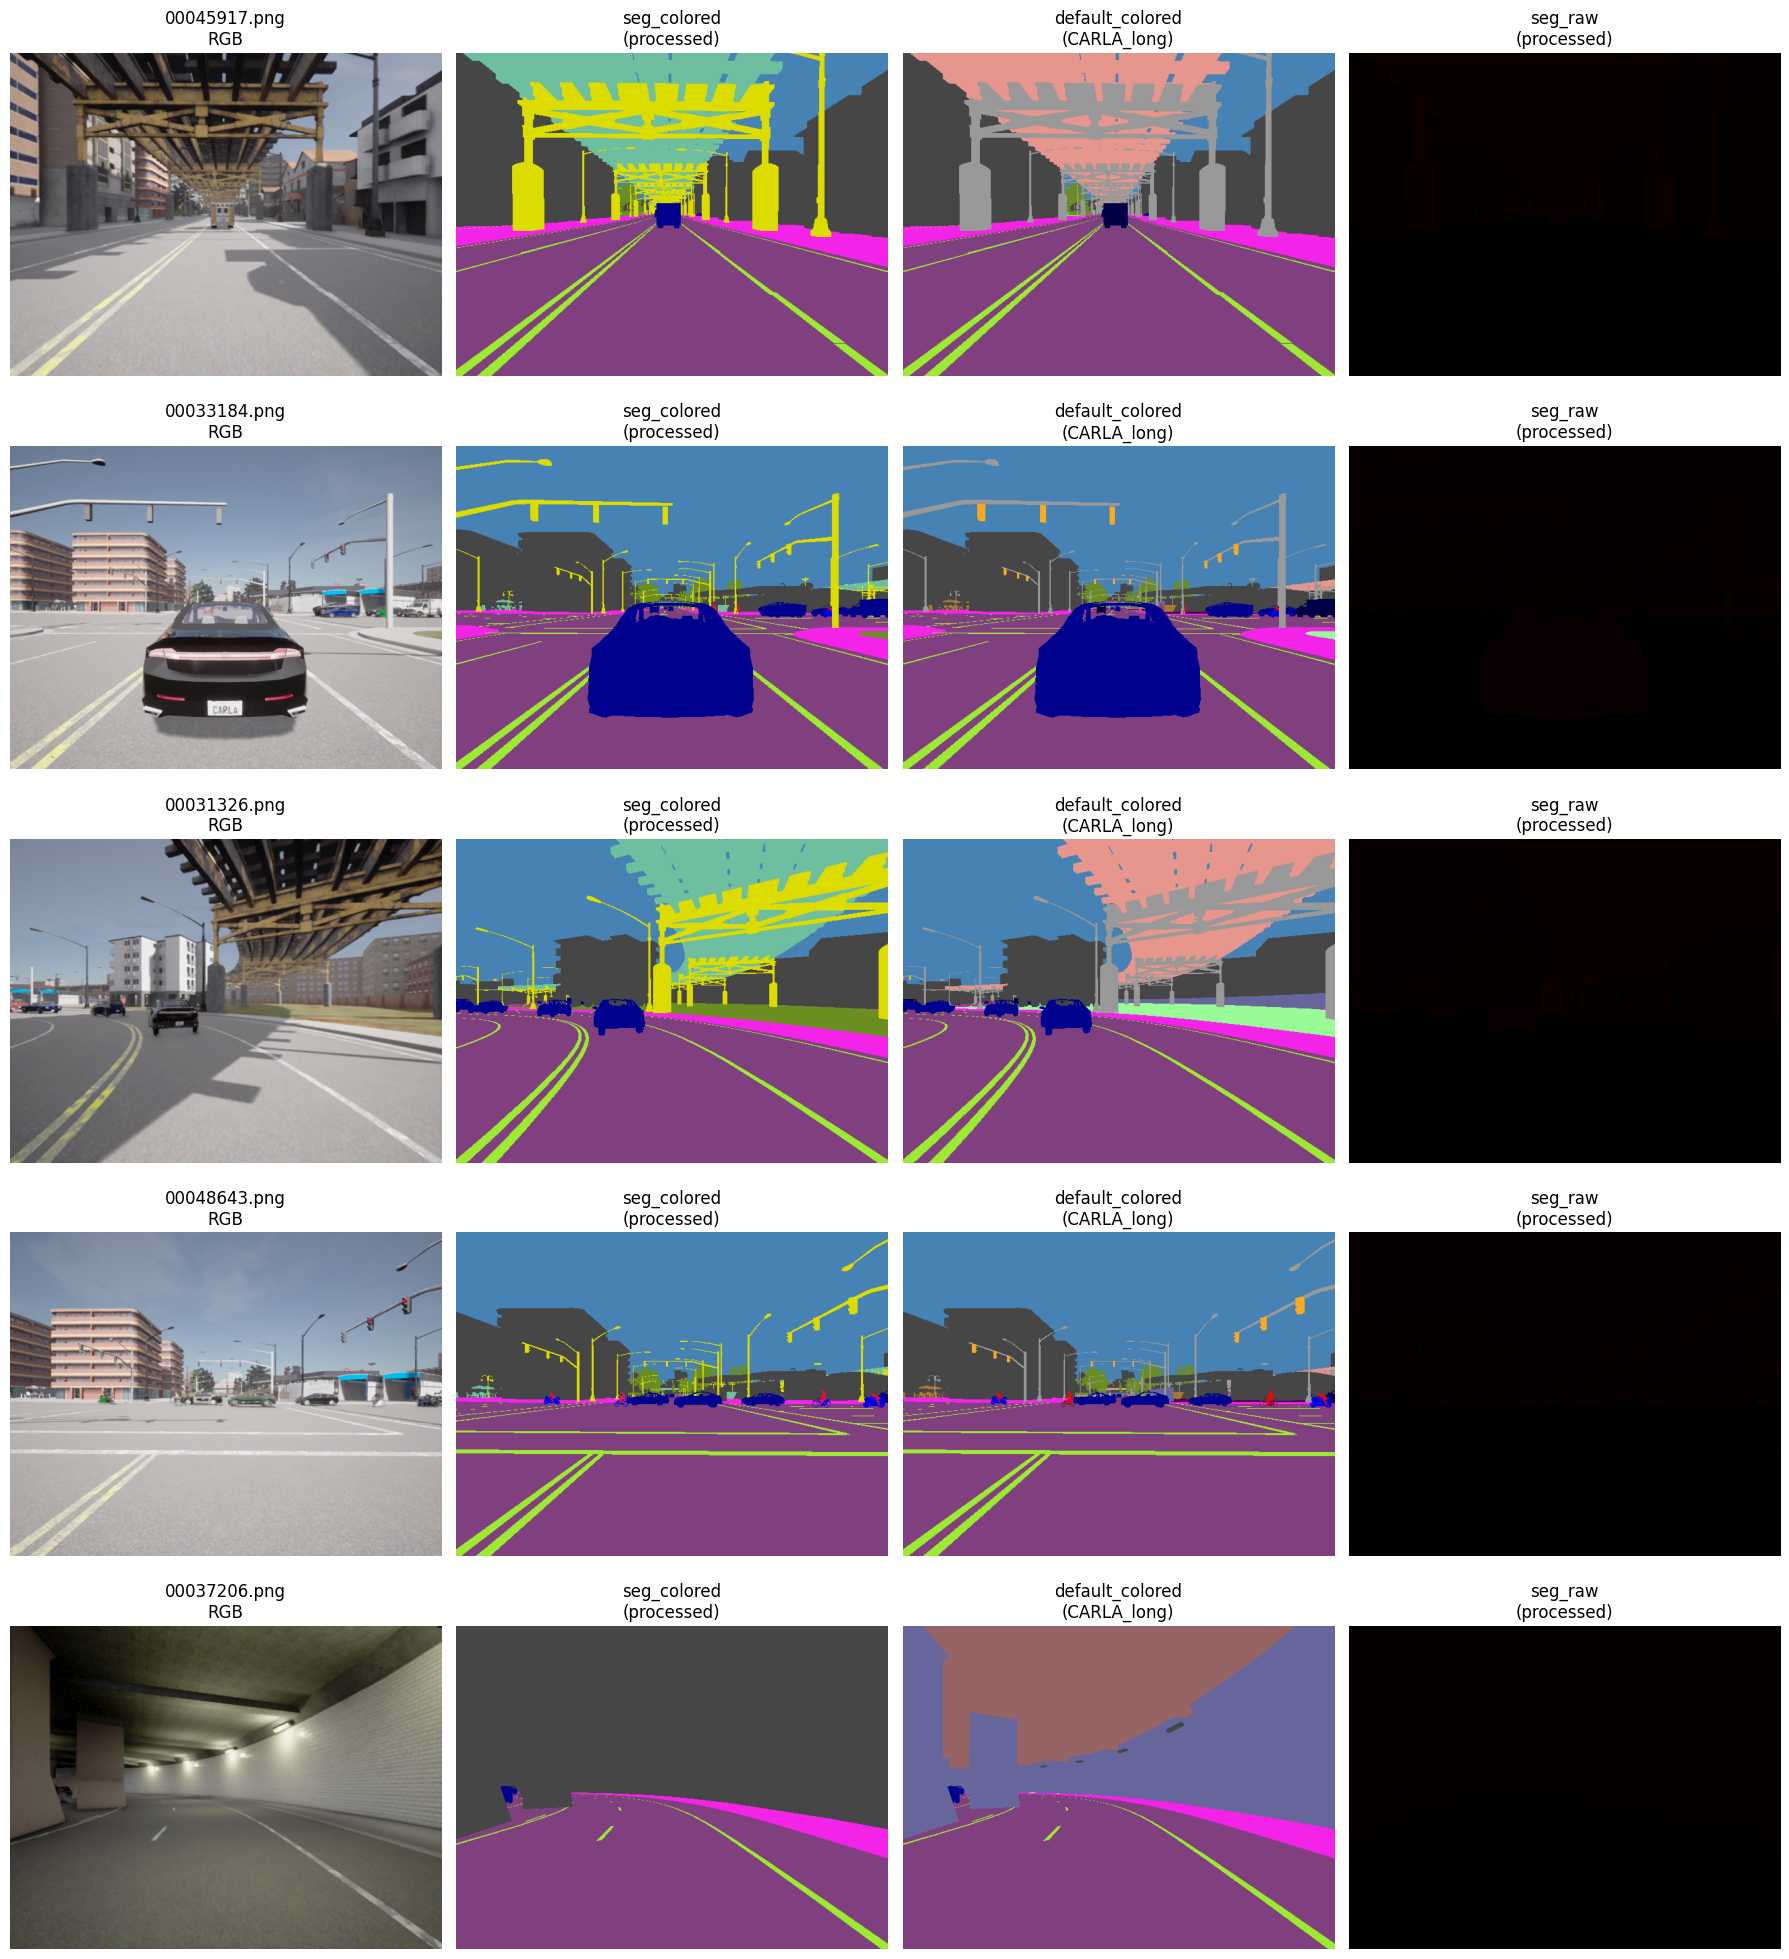

In [8]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

SEQ_ID = "00"
SEQ_OUT = Path(merged_dataset_root) / SEQ_ID
SEQ_SRC = Path(raw_dataset_root) / SEQ_ID
N_SAMPLES = 5
RNG = random.Random(42)

names = sorted(p.name for p in (SEQ_OUT / "rgb").iterdir() if p.suffix.lower() == ".png")
picked = RNG.sample(names, min(N_SAMPLES, len(names)))


def _rgb_unique(arr: np.ndarray) -> list[tuple[int, int, int]]:
    rgb = arr[..., :3] if arr.ndim == 3 else arr
    rows = np.unique(rgb.reshape(-1, 3), axis=0)
    return [tuple(int(x) for x in row) for row in rows]


for name in picked:
    col = np.array(Image.open(SEQ_OUT / "segmentation_colored" / name))
    default_col = np.array(Image.open(SEQ_SRC / "segmentation_colored" / name))
    raw = np.array(Image.open(SEQ_OUT / "segmentation_raw" / name))

    print(f"\n=== {name} ===")
    print("default_colored (CARLA_long) unique RGB:")
    for row in _rgb_unique(default_col):
        print(f"  {row}")
    print("segmentation_colored (processed) unique RGB:")
    for row in _rgb_unique(col):
        print(f"  {row}")
    print("segmentation_raw unique R:", sorted(int(x) for x in np.unique(raw[..., 0])))

fig, axes = plt.subplots(len(picked), 4, figsize=(18, 4 * len(picked)))
if len(picked) == 1:
    axes = axes[np.newaxis, :]

for row, name in enumerate(picked):
    rgb = np.array(Image.open(SEQ_OUT / "rgb" / name).convert("RGB"))
    col = np.array(Image.open(SEQ_OUT / "segmentation_colored" / name))
    default_col = np.array(Image.open(SEQ_SRC / "segmentation_colored" / name))
    raw = np.array(Image.open(SEQ_OUT / "segmentation_raw" / name))

    if col.shape[-1] == 4:
        col = col[..., :3]
    if default_col.shape[-1] == 4:
        default_col = default_col[..., :3]
    raw_vis = raw[..., :3] if raw.ndim == 3 and raw.shape[-1] >= 3 else raw

    axes[row, 0].imshow(rgb)
    axes[row, 0].set_title(f"{name}\nRGB")
    axes[row, 1].imshow(col)
    axes[row, 1].set_title("seg_colored\n(processed)")
    axes[row, 2].imshow(default_col)
    axes[row, 2].set_title("default_colored\n(CARLA_long)")
    axes[row, 3].imshow(raw_vis)
    axes[row, 3].set_title("seg_raw\n(processed)")
    for c in range(4):
        axes[row, c].axis("off")

plt.tight_layout()
plt.show()

In [7]:
# import random
# from pathlib import Path

# import matplotlib.pyplot as plt
# import numpy as np
# from PIL import Image

# SEQ = Path(merged_dataset_root) / "00"
# N_SAMPLES = 5
# RNG = random.Random(42)

# names = sorted(p.name for p in (SEQ / "rgb").iterdir() if p.suffix.lower() == ".png")
# picked = RNG.sample(names, min(N_SAMPLES, len(names)))

# for name in picked:
#     col = np.array(Image.open(SEQ / "segmentation_colored" / name))
#     raw = np.array(Image.open(SEQ / "segmentation_raw" / name))

#     col_rgb = col[..., :3] if col.ndim == 3 else col
#     col_unique = np.unique(col_rgb.reshape(-1, 3), axis=0)
#     raw_unique = np.unique(raw[..., 0])

#     print(f"\n=== {name} ===")
#     print("segmentation_colored unique RGB:")
#     for row in col_unique:
#         print(f"  {tuple(int(x) for x in row)}")
#     print("segmentation_raw unique R:", sorted(int(x) for x in raw_unique))

# fig, axes = plt.subplots(len(picked), 3, figsize=(14, 4 * len(picked)))
# if len(picked) == 1:
#     axes = axes[np.newaxis, :]

# for row, name in enumerate(picked):
#     rgb = np.array(Image.open(SEQ / "rgb" / name).convert("RGB"))
#     col = np.array(Image.open(SEQ / "segmentation_colored" / name))
#     raw = np.array(Image.open(SEQ / "segmentation_raw" / name))

#     if col.shape[-1] == 4:
#         col = col[..., :3]
#     raw_vis = raw[..., :3] if raw.ndim == 3 and raw.shape[-1] >= 3 else raw

#     axes[row, 0].imshow(rgb)
#     axes[row, 0].set_title(f"{name}\nRGB")
#     axes[row, 1].imshow(col)
#     axes[row, 1].set_title("segmentation_colored")
#     axes[row, 2].imshow(raw_vis)
#     axes[row, 2].set_title("segmentation_raw")
#     for c in range(3):
#         axes[row, c].axis("off")

# plt.tight_layout()
# plt.show()


